LTM- Creating New Memories

In [4]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

1. Creating LTMStore

In [5]:
store = InMemoryStore()

In [6]:
#2. Creating LTM  that decides what to remember -in form of structured output

In [7]:
extractor_llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [8]:
#creating store structure using pydantic
class MemoryDecision(BaseModel):
    should_write: bool =Field(description = "Wheter to store  msg in memory or not")
    memories : List[str] = Field(default_factory= list, description = "User memories to store")

In [25]:
#memory extractor should be in the structured output form of MemoryDecision pydantic model as we defined above
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

3. Creating Graph - to check remember node
START -> remember -> END
 (Creates memories, but does NOT use them to answer)

In [27]:
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

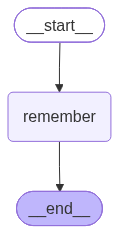

In [21]:
builder = StateGraph(MessagesState)
builder.add_node("remember",remember_only_node)

builder.add_edge(START,"remember")
builder.add_edge("remember",END)

graph = builder.compile(store= store)
graph

DEMO

In [33]:
config = {"configurable":{"user_id":"u1"}}

result = graph.invoke({"messages":[{"role":"user","content":"Hi my name is Nazia"}]},config)

print("Assistant :",result["messages"][-1].content)

Assistant : Noted.


In [32]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [ ]:
#checking what has been in store

items = store.search(("user","u1","details"))
for item in items:
    print(item.value["data"]) #we can see the duplication in storing 

User's name is Nazia
User's favorite programming language is Python.
User's favorite programming language is Python.
User's name is Nazia.
